In [1]:
##
import os
import re
import cv2
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import shutil
import tensorflow as tf 
from PIL import Image
import copy
from sklearn.metrics import accuracy_score, roc_auc_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, MaxPooling2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB3  
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint
import pandas as pd

import logging
logging.basicConfig(level=logging.INFO)

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
##
import shutil
import os

# 👇 List of folders you want to delete (add more if needed)
folders_to_delete = [
    '/kaggle/working/melanoma-dataset-clean',
    '/kaggle/working/train',
    '/kaggle/working/val',
    '/kaggle/working/test',
]

for folder in folders_to_delete:
    if os.path.exists(folder):
        shutil.rmtree(folder)
        print(f"🧽 Deleted: {folder}")
    else:
        print(f"✅ Already clean: {folder}")


✅ Already clean: /kaggle/working/melanoma-dataset-clean
✅ Already clean: /kaggle/working/train
✅ Already clean: /kaggle/working/val
✅ Already clean: /kaggle/working/test


In [3]:
import os
from collections import Counter

def count_image_extensions(root_dir):
    extensions = Counter()

    for subdir, _, files in os.walk(root_dir):
        for file in files:
            ext = os.path.splitext(file)[1].lower()
            if ext in ['.jpg', '.jpeg', '.png', '.bmp', '.gif', '.tiff']:
                extensions[ext] += 1

    return extensions

# 🔎 Set this to your clean dataset path
dataset_path = '/kaggle/working/melanoma-dataset-clean'

# 🧾 Run extension counter
ext_counts = count_image_extensions(dataset_path)

# 📊 Show results
print("🧠 Image File Formats Found:")
for ext, count in ext_counts.items():
    print(f"{ext}: {count} files")


🧠 Image File Formats Found:


In [4]:
##
import os
import shutil
from sklearn.model_selection import train_test_split

# 🗂️ Original dataset path (from Kaggle dataset)
original_train_dir = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
original_test_dir = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'

# 🆕 Destination for clean split
base_dir = '/kaggle/working/melanoma-dataset-clean'
os.makedirs(base_dir, exist_ok=True)

for split in ['train', 'val', 'test']:
    for cls in ['benign', 'malignant']:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

# 🟩 Step 1: Get all image paths + labels from the original train set
all_image_paths = []
all_labels = []

for label in ['benign', 'malignant']:
    full_path = os.path.join(original_train_dir, label)
    for fname in os.listdir(full_path):
        if fname.endswith(('.jpg')):
            all_image_paths.append(os.path.join(full_path, fname))
            all_labels.append(label)

# 🟨 Step 2: Split train into train + val (80/20)
train_imgs, val_imgs, train_labels, val_labels = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# 🔁 Step 3: Copy files to new folders
def copy_images(image_paths, labels, dest_dir):
    seen = set()
    for src, lbl in zip(image_paths, labels):
        fname = os.path.basename(src)
        dest = os.path.join(dest_dir, lbl, fname)

        if fname not in seen:  # ensure no duplicates
            shutil.copy2(src, dest)
            seen.add(fname)

copy_images(train_imgs, train_labels, os.path.join(base_dir, 'train'))
copy_images(val_imgs, val_labels, os.path.join(base_dir, 'val'))

# 🟥 Step 4: Copy test images AS-IS (since test is already separate and clean)
for label in ['benign', 'malignant']:
    test_src = os.path.join(original_test_dir, label)
    test_dst = os.path.join(base_dir, 'test', label)

    for fname in os.listdir(test_src):
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            shutil.copy2(os.path.join(test_src, fname), os.path.join(test_dst, fname))

print("✅ Dataset clean split complete!")


✅ Dataset clean split complete!


In [8]:
folders = [
    "train/benign", "train/malignant",
    "val/benign", "val/malignant",
    "test/benign", "test/malignant"
]

def check_filename_consistency(dataset_path, subfolders):
    issues_found = False
    for subfolder in subfolders:
        folder_path = os.path.join(dataset_path, subfolder)
        if os.path.exists(folder_path):
            for filename in os.listdir(folder_path):
                if not re.match(r"melanoma_\d+\.jpg$", filename):
                    print(f"Issue in {subfolder}: {filename}")
                    issues_found = True
    if not issues_found:
        print("✅ All filenames consistent!")

# Example usage
check_filename_consistency(dataset_path, folders)



✅ All filenames consistent!


In [9]:
import os

def count_images_in_folders(base_dir, folder_list):
    counts = {}
    for folder in folder_list:
        folder_path = os.path.join(base_dir, folder)
        if os.path.exists(folder_path):
            # Count only valid image files
            counts[folder] = len([
                f for f in os.listdir(folder_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
        else:
            counts[folder] = 0
    return counts

# 🧠 Define your cleaned dataset path
dataset_path = "/kaggle/working/melanoma-dataset-clean"

# 🔍 All folders to check
folders = [
    "train/benign", "train/malignant",
    "val/benign", "val/malignant",
    "test/benign", "test/malignant"
]

# 📊 Count images
image_counts = count_images_in_folders(dataset_path, folders)

# 🖨️ Display results
print("📦 Image Counts by Folder:")
for folder, count in image_counts.items():
    print(f"{folder}: {count} images")


📦 Image Counts by Folder:
train/benign: 4000 images
train/malignant: 3684 images
val/benign: 1000 images
val/malignant: 921 images
test/benign: 500 images
test/malignant: 500 images


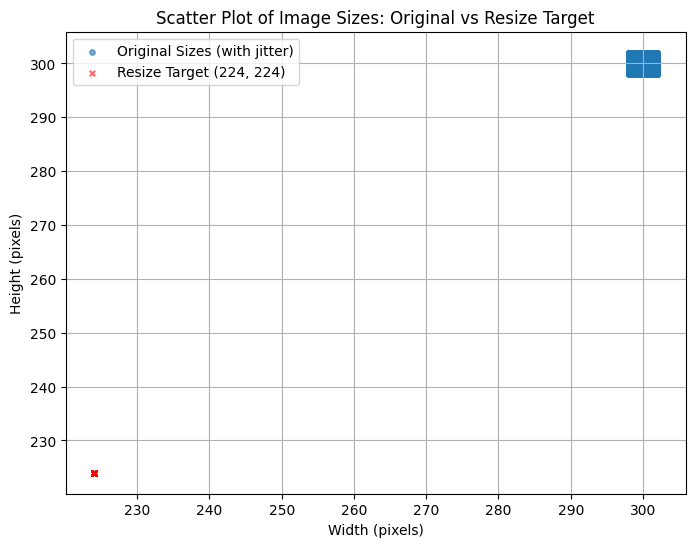

In [10]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Your dataset folders
dataset_path = '/kaggle/working/melanoma-dataset-clean'
folders = [
    'train/benign', 'train/malignant',
    'val/benign', 'val/malignant',
    'test/benign', 'test/malignant'
]

def get_all_image_sizes(base_path, folder_list):
    sizes = []
    for folder in folder_list:
        folder_path = os.path.join(base_path, folder)
        if os.path.exists(folder_path):
            for f in os.listdir(folder_path):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    img = Image.open(os.path.join(folder_path, f))
                    sizes.append(img.size)
    return sizes

original_sizes = get_all_image_sizes(dataset_path, folders)
widths, heights = zip(*original_sizes)

# Resize target
resize_to = (224, 224)
resize_widths = np.full(len(original_sizes), resize_to[0])
resize_heights = np.full(len(original_sizes), resize_to[1])

# Add small jitter to visualize points better
jitter_strength = 2
widths_jitter = np.array(widths) + np.random.uniform(-jitter_strength, jitter_strength, len(widths))
heights_jitter = np.array(heights) + np.random.uniform(-jitter_strength, jitter_strength, len(heights))

plt.figure(figsize=(8,6))
plt.scatter(widths_jitter, heights_jitter, alpha=0.6, label='Original Sizes (with jitter)', s=15)
plt.scatter(resize_widths, resize_heights, alpha=0.6, label=f'Resize Target {resize_to}', s=15, marker='x', color='red')

plt.xlabel('Width (pixels)')
plt.ylabel('Height (pixels)')
plt.title('Scatter Plot of Image Sizes: Original vs Resize Target')
plt.legend()
plt.grid(True)
plt.show()


In [15]:
train_path = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/train'
def compute_mean_std(directory):
    images = []
    for class_name in os.listdir(directory):
        class_path = os.path.join(directory, class_name)
        for img_name in os.listdir(class_path)[:100]:
            img = load_img(os.path.join(class_path, img_name))
            img_array = img_to_array(img) / 255.0
            images.append(img_array)
    images = np.array(images)
    mean = np.mean(images, axis=(0, 1, 2))
    std = np.std(images, axis=(0, 1, 2))
    return mean, std

mean, std = compute_mean_std(train_path)
print(f"Mean: {mean}, Standard Deviation: {std}")

Mean: [0.7914102  0.57695764 0.5331515 ], Standard Deviation: [0.22552127 0.20045672 0.21367061]


In [19]:
import tensorflow as tf
import os
import numpy as np
from PIL import Image

# Mean and std values for normalization
MEAN = tf.constant([0.7914102, 0.57695764, 0.5331515])
STD = tf.constant([0.22552127, 0.20045672, 0.21367061])

# Image size
IMG_SIZE = (224, 224)

# Class label mapping (ensure folder names match)
CLASS_NAMES = ['benign', 'malignant']
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

# Function to load and preprocess an image
def preprocess_image(file_path, label, augment=False, is_malignant=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # scale to [0,1]
    
    if augment:
        img = tf.image.random_crop(tf.image.resize_with_crop_or_pad(img, 230, 230), size=[224, 224, 3])
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, lower=0.7, upper=1.3)
        img = tf.image.random_saturation(img, lower=0.7, upper=1.3)
        img = tf.image.random_hue(img, max_delta=0.1)
    else:
        img = tf.image.resize(img, IMG_SIZE)

    # Normalize using provided mean/std
    img = (img - MEAN) / STD
    return img, label

# Function to build a tf.data.Dataset from directory
def build_dataset(directory, split='train', batch_size=32, shuffle=True):
    file_paths = []
    labels = []

    for class_name in CLASS_NAMES:
        class_dir = os.path.join(directory, class_name)
        image_files = [os.path.join(class_dir, fname) for fname in os.listdir(class_dir) if fname.lower().endswith(('.jpg', '.jpeg', '.png'))]
        file_paths.extend(image_files)
        labels.extend([CLASS_TO_IDX[class_name]] * len(image_files))

    file_paths = tf.constant(file_paths)
    labels = tf.constant(labels)

    dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))

    def map_fn(file_path, label):
        is_malignant = tf.equal(label, CLASS_TO_IDX['malignant'])
        augment = tf.equal(split, 'train')
        return preprocess_image(file_path, label, augment=augment, is_malignant=is_malignant)

    dataset = dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle and split == 'train':
        dataset = dataset.shuffle(buffer_size=1000)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

# Paths (replace with actual ones)
train_path = '/kaggle/working/melanoma-dataset-clean/train'
val_path = '/kaggle/working/melanoma-dataset-clean/val'
test_path = '/kaggle/working/melanoma-dataset-clean/test'

# Build datasets
train_ds = build_dataset(train_path, split='train')
val_ds = build_dataset(val_path, split='val', shuffle=False)
test_ds = build_dataset(test_path, split='test', shuffle=False)

print("✅ TensorFlow datasets ready!")


✅ TensorFlow datasets ready!


In [22]:
import tensorflow as tf
import numpy as np
import os
import random

# Mean and std used for normalization
MEAN = tf.constant([0.7914102, 0.57695764, 0.5331515], dtype=tf.float32)
STD = tf.constant([0.22552127, 0.20045672, 0.21367061], dtype=tf.float32)

IMG_SIZE = (224, 224)

# Image stats (mean/std per channel) for normalized tensors
def image_stats(tensor_img):
    # tensor_img shape: (H, W, C)
    np_img = tensor_img.numpy()
    mean_per_channel = np.mean(np_img, axis=(0, 1))
    std_per_channel = np.std(np_img, axis=(0, 1))
    return mean_per_channel, std_per_channel

# Load and normalize image (optionally augment)
def preprocess_image(file_path, augment=False):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0, 1]

    if augment:
        img = tf.image.resize_with_crop_or_pad(img, 230, 230)
        img = tf.image.random_crop(img, size=[224, 224, 3])
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.3)
        img = tf.image.random_contrast(img, lower=0.7, upper=1.3)
        img = tf.image.random_saturation(img, lower=0.7, upper=1.3)
        img = tf.image.random_hue(img, max_delta=0.1)
    else:
        img = tf.image.resize(img, IMG_SIZE)

    # Normalize using mean and std
    img = (img - MEAN) / STD
    return img

# Class mapping (same as before)
class_to_idx = {'benign': 0, 'malignant': 1}

# Get file paths and labels from your dataset
def get_image_paths_and_labels(root_dir):
    image_paths = []
    labels = []

    for class_name in ['benign', 'malignant']:
        class_dir = os.path.join(root_dir, class_name)
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, fname))
                labels.append(class_to_idx[class_name])
    return image_paths, labels

# Replace this with your actual train directory
train_dir = '/kaggle/working/melanoma-dataset-clean/train'
train_image_paths, train_labels = get_image_paths_and_labels(train_dir)

# 🔬 Analyze a malignant image
malignant_indices = [i for i, lbl in enumerate(train_labels) if lbl == class_to_idx['malignant']]
idx_malignant = random.choice(malignant_indices)
malignant_path = train_image_paths[idx_malignant]

# Load image without augmentation
orig_malignant_tensor = preprocess_image(malignant_path, augment=False)
orig_mean, orig_std = image_stats(orig_malignant_tensor)

# Load image with augmentation
aug_malignant_tensor = preprocess_image(malignant_path, augment=True)
aug_mean, aug_std = image_stats(aug_malignant_tensor)

print(f"Malignant image original mean per channel: {orig_mean}")
print(f"Malignant image original std per channel: {orig_std}")
print(f"Malignant image augmented mean per channel: {aug_mean}")
print(f"Malignant image augmented std per channel: {aug_std}")

# 🔬 Analyze a benign image (only minimal transform)
benign_indices = [i for i, lbl in enumerate(train_labels) if lbl == class_to_idx['benign']]
idx_benign = random.choice(benign_indices)
benign_path = train_image_paths[idx_benign]

orig_benign_tensor = preprocess_image(benign_path, augment=False)
trans_benign_tensor = preprocess_image(benign_path, augment=False)

orig_benign_mean, orig_benign_std = image_stats(orig_benign_tensor)
trans_benign_mean, trans_benign_std = image_stats(trans_benign_tensor)

print(f"Benign image original mean per channel: {orig_benign_mean}")
print(f"Benign image original std per channel: {orig_benign_std}")
print(f"Benign image transformed mean per channel: {trans_benign_mean}")
print(f"Benign image transformed std per channel: {trans_benign_std}")


Malignant image original mean per channel: [-0.5702509   0.09931257 -0.19199872]
Malignant image original std per channel: [0.6093514  0.7833656  0.80792904]
Malignant image augmented mean per channel: [-1.6037624 -0.8213842 -1.4386095]
Malignant image augmented std per channel: [0.62316036 0.7373689  0.683764  ]
Benign image original mean per channel: [-0.91185635 -0.7465746  -0.629271  ]
Benign image original std per channel: [0.16868152 0.30613223 0.39065415]
Benign image transformed mean per channel: [-0.91185635 -0.7465746  -0.629271  ]
Benign image transformed std per channel: [0.16868152 0.30613223 0.39065415]


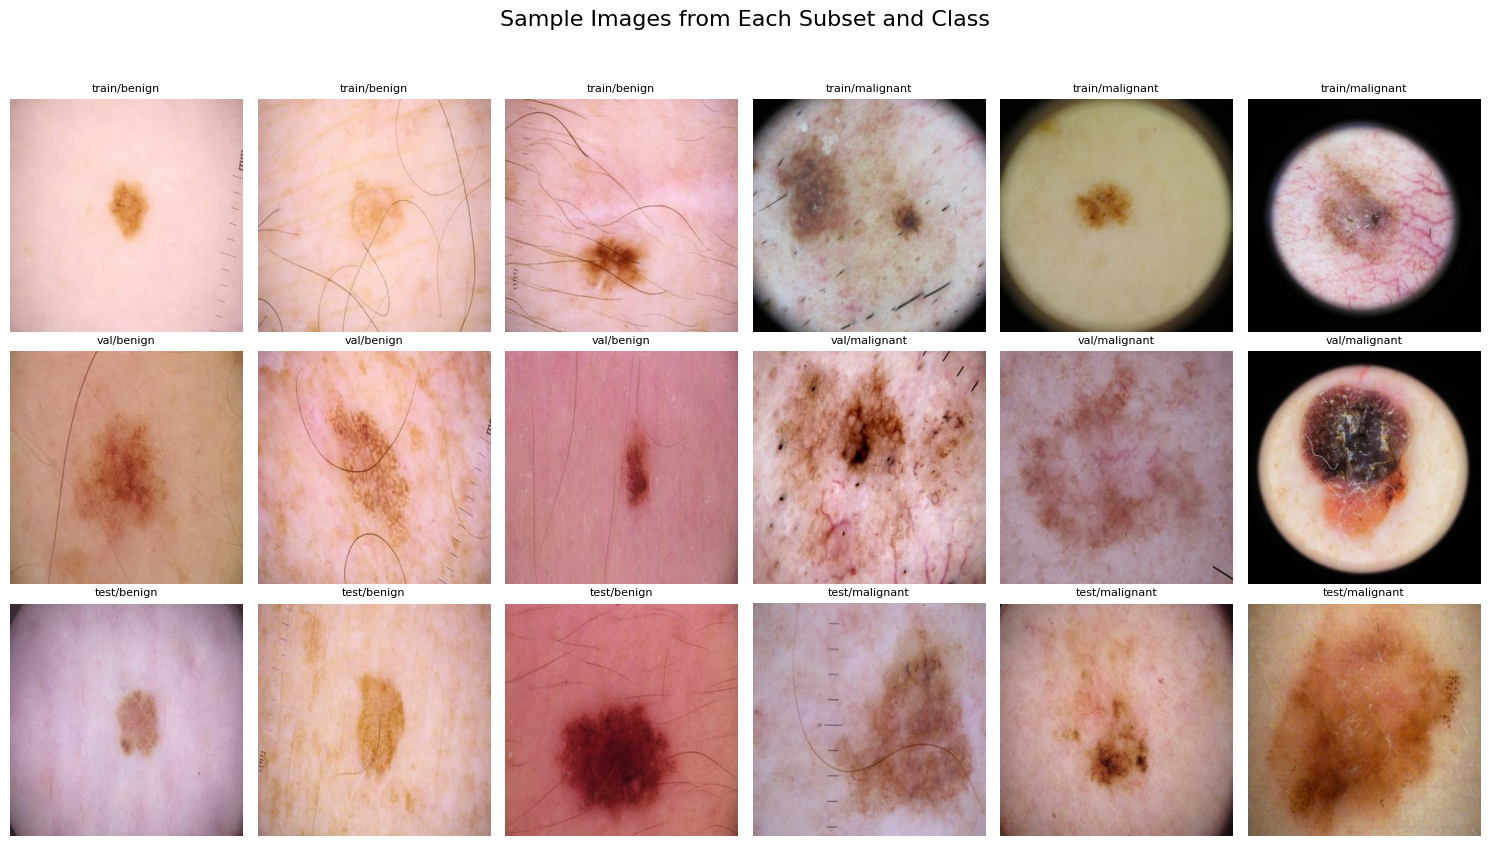

In [28]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

# Define root paths
dataset_root = '/kaggle/working/melanoma-dataset-clean'
subsets = ['train', 'val', 'test']
classes = ['benign', 'malignant']

# Plot 3 images from each class in each subset
fig, axes = plt.subplots(len(subsets), len(classes) * 3, figsize=(15, 9))
fig.suptitle('Sample Images from Each Subset and Class', fontsize=16)

for row, subset in enumerate(subsets):
    for col_class, cls in enumerate(classes):
        folder_path = os.path.join(dataset_root, subset, cls)
        img_files = sorted([
            f for f in os.listdir(folder_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])[:3]
        
        for i, img_name in enumerate(img_files):
            img_path = os.path.join(folder_path, img_name)
            img_raw = tf.io.read_file(img_path)
            img_tensor = tf.image.decode_image(img_raw, channels=3)
            img_tensor = tf.image.convert_image_dtype(img_tensor, tf.float32)
            
            ax = axes[row, col_class * 3 + i]
            ax.imshow(img_tensor.numpy())
            ax.axis('off')
            ax.set_title(f'{subset}/{cls}', fontsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


In [44]:
import tensorflow as tf
test_dir = '/kaggle/input/melanoma-skin-cancer-dataset-of-10000-images/melanoma_cancer_dataset/test'
img_size = (224, 224)
batch_size = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='binary',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


for images, labels in train_ds.take(1):
    print("Images shape:", images.shape)   # (32, 224, 224, 3)
    print("Labels shape:", labels.shape)   # (32,)



Found 7684 files belonging to 2 classes.
Found 1921 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Images shape: (8, 224, 224, 3)
Labels shape: (8, 1)


In [30]:
def train_and_checkpoint(model, checkpoint_path, epochs=5):
    checkpoint_cb = ModelCheckpoint(checkpoint_path, save_best_only=True, monitor='val_auc', mode='max')
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=[checkpoint_cb])
    return history

def evaluate_train_and_test(model, checkpoint_path):
    model.load_weights(checkpoint_path)
    print("Evaluating on Train Dataset:")
    train_loss, train_acc, train_auc = model.evaluate(train_ds)
    print("Evaluating on Test Dataset:")
    test_loss, test_acc, test_auc = model.evaluate(test_ds)
    return {
        "Train Accuracy": train_acc,
        "Train AUC": train_auc,
        "Test Accuracy": test_acc,
        "Test AUC": test_auc
    }


In [31]:
#### mostttt imp
#custom cnn baseline

def create_simple_cnn():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Conv2D(32, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model



In [32]:
# Create model instance
simple_cnn_model = create_simple_cnn()

# Train and checkpoint
checkpoint_path = "best_simple_cnn.keras"
history = train_and_checkpoint(simple_cnn_model, checkpoint_path, epochs=5)
    

Epoch 1/5
961/961 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - accuracy: 0.6792 - auc: 0.6878 - loss: 102.0442 - val_accuracy: 0.7694 - val_auc: 0.8494 - val_loss: 0.4875
Epoch 2/5
961/961 ━━━━━━━━━━━━━━━━━━━━ 18s 19ms/step - accuracy: 0.7965 - auc: 0.8680 - loss: 0.4510 - val_accuracy: 0.8084 - val_auc: 0.8850 - val_loss: 0.4889
Epoch 3/5
961/961 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7881 - auc: 0.8579 - loss: 0.4493 - val_accuracy: 0.7158 - val_auc: 0.7586 - val_loss: 0.5677
Epoch 4/5
961/961 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.7833 - auc: 0.8238 - loss: 0.4779 - val_accuracy: 0.6830 - val_auc: 0.6935 - val_loss: 0.6140
Epoch 5/5
961/961 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.7443 - auc: 0.7580 - loss: 0.5437 - val_accuracy: 0.6736 - val_auc: 0.6701 - val_loss: 0.5868


In [33]:
metrics_simple_cnn = evaluate_train_and_test(simple_cnn_model, "best_simple_cnn.keras")
print(metrics_simple_cnn)


Evaluating on Train Dataset:
961/961 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8589 - auc: 0.9351 - loss: 0.3799
Evaluating on Test Dataset:
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7774 - auc: 0.4347 - loss: 0.5015
{'Train Accuracy': 0.8650442361831665, 'Train AUC': 0.940022885799408, 'Test Accuracy': 0.7990000247955322, 'Test AUC': 0.8856779932975769}


In [46]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses, metrics
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
val_dir = '/kaggle/working/melanoma-dataset-clean/val'
# === Define the CNN model (equivalent to the PyTorch version) ===
def build_simple_cnn():
    model = models.Sequential([
        layers.Input(shape=(224, 224, 3)),
        layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),
        layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'),
        layers.MaxPooling2D(pool_size=2),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

# === Custom training and evaluation logic (to match PyTorch flow) ===
def train_model(model, train_dataset, val_dataset, epochs=5, lr=1e-3):
    optimizer = optimizers.Adam(learning_rate=lr)
    loss_fn = losses.BinaryCrossentropy()
    best_val_auc = 0.0
    best_weights = None

    for epoch in range(epochs):
        print(f"\nEpoch {epoch + 1}/{epochs}")

        # Training
        train_loss = metrics.Mean()
        y_true_train, y_pred_train = [], []
        for images, labels in train_dataset:
            with tf.GradientTape() as tape:
                predictions = model(images, training=True)
                loss = loss_fn(labels, predictions)
            grads = tape.gradient(loss, model.trainable_variables)
            optimizer.apply_gradients(zip(grads, model.trainable_variables))
            train_loss.update_state(loss)
            y_true_train.extend(labels.numpy())
            y_pred_train.extend(predictions.numpy())

        train_preds_bin = [1 if p > 0.5 else 0 for p in y_pred_train]
        train_acc = accuracy_score(y_true_train, train_preds_bin)
        train_auc = roc_auc_score(y_true_train, y_pred_train)

        # Validation
        y_true_val, y_pred_val = [], []
        for images, labels in val_dataset:
            predictions = model(images, training=False)
            y_true_val.extend(labels.numpy())
            y_pred_val.extend(predictions.numpy())

        val_preds_bin = [1 if p > 0.5 else 0 for p in y_pred_val]
        val_acc = accuracy_score(y_true_val, val_preds_bin)
        val_auc = roc_auc_score(y_true_val, y_pred_val)

        print(f"Train Loss: {train_loss.result():.4f} | Train Acc: {train_acc:.4f} | Train AUC: {train_auc:.4f} | Val Acc: {val_acc:.4f} | Val AUC: {val_auc:.4f}")

        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_weights = model.get_weights()

    if best_weights:
        model.set_weights(best_weights)
    return model

# === Evaluation Function ===
def evaluate_model(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        predictions = model(images, training=False)
        y_true.extend(labels.numpy())
        y_pred.extend(predictions.numpy())

    preds_bin = [1 if p > 0.5 else 0 for p in y_pred]
    acc = accuracy_score(y_true, preds_bin)
    auc = roc_auc_score(y_true, y_pred)
    return acc, auc

# === Usage Example (Assuming tf.data.Datasets are ready) ===
# train_dataset = ... (must yield (image_batch, label_batch) with float32 labels)
# val_dataset = ...
# test_dataset = ...



In [47]:
model = build_simple_cnn()
trained_model = train_model(model, train_dataset, val_dataset, epochs=5, lr=1e-3)
train_acc, train_auc = evaluate_model(trained_model, train_dataset)
test_acc, test_auc = evaluate_model(trained_model, test_dataset)

print(f"\nFinal Train Accuracy: {train_acc:.4f}, Train AUC: {train_auc:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}, Test AUC: {test_auc:.4f}")



Epoch 1/5
Train Loss: 9.0986 | Train Acc: 0.7348 | Train AUC: 0.7891 | Val Acc: 0.7153 | Val AUC: 0.8271

Epoch 2/5
Train Loss: 0.4537 | Train Acc: 0.7945 | Train AUC: 0.8621 | Val Acc: 0.7408 | Val AUC: 0.8588

Epoch 3/5
Train Loss: 0.4260 | Train Acc: 0.8039 | Train AUC: 0.8744 | Val Acc: 0.7980 | Val AUC: 0.8804

Epoch 4/5
Train Loss: 0.4112 | Train Acc: 0.8119 | Train AUC: 0.8848 | Val Acc: 0.8121 | Val AUC: 0.8906

Epoch 5/5
Train Loss: 0.3937 | Train Acc: 0.8183 | Train AUC: 0.8965 | Val Acc: 0.8204 | Val AUC: 0.8977

Final Train Accuracy: 0.8280, Train AUC: 0.9098
Final Test Accuracy: 0.8540, Test AUC: 0.9242
